# Unified Facial Emotion Recognition Pipeline
## Combined FER-2013 + AffectNet + RAF-DB → EfficientNet-B3 + DenseNet-121 Ensemble

### Pipeline Overview:
1. **Unified Dataset** — Load, clean, and merge all 3 datasets (224×224 RGB, 6-class)
2. **Domain-Bridging Augmentations** — RandomGrayscale + GaussianBlur to bridge quality/color gaps
3. **Dual Model Training** — EfficientNet-B3 (efficient) + DenseNet-121 (dense connections)
4. **Focal Loss** with label smoothing
5. **Progressive Unfreezing** + Cosine Annealing with Warmup
6. **TTA + Weighted Ensemble** inference
7. **Evaluation** on all 3 test sets

### Kaggle Setup:
1. Add dataset: `vikashkumar999/facial-expression-recognition` (FER-2013)
2. Add dataset: `mstjebashazida/affectnet` (AffectNet)
3. Add dataset: `shuvoalok/raf-db-dataset` (RAF-DB)
4. Settings → Accelerator → **GPU P100/T4**
5. *(Optional)* Secrets → `RCLONE_CONF` for Google Drive sync
6. **Run All**

## 1. Environment Setup

In [1]:
# ===== KAGGLE-SAFE ENVIRONMENT SETUP =====
# CRITICAL: Kaggle pre-installs numpy, scipy, torch, torchvision, timm,
# scikit-learn, pandas, pillow, matplotlib, seaborn, tqdm, opencv-python.
# We ONLY install packages NOT pre-installed (facenet-pytorch).
# DO NOT downgrade/upgrade core packages — this causes binary incompatibility!

import subprocess, sys, warnings
warnings.filterwarnings('ignore')

def run_pip(cmd):
    """Execute pip command and return success status."""
    result = subprocess.run([sys.executable, '-m', 'pip'] + cmd,
                            capture_output=True, text=True)
    return result.returncode == 0

print('=' * 60)
print('KAGGLE ENVIRONMENT SETUP (Minimal — Pre-installed Only)')
print('=' * 60)

# ── Install ONLY facenet-pytorch (not pre-installed on Kaggle) ────────────
print('\n[1/1] Installing facenet-pytorch (only non-pre-installed package)...')
print('  Using --no-deps to avoid binary incompatibility issues...')
ok = run_pip(['install', 'facenet-pytorch', '--no-deps', '-q'])
if ok:
    print('  ✓ facenet-pytorch installed successfully')
else:
    print('  ⚠ facenet-pytorch install had issues — will retry on import')

# ── Verify critical imports (non-interactive) ──────────────────────────────
print('\n' + '=' * 60)
print('VERIFYING CRITICAL IMPORTS')
print('=' * 60)

critical_imports = [
    ('numpy',       'numpy'),
    ('scipy',       'scipy'),
    ('torch',       'torch'),
    ('torchvision', 'torchvision'),
    ('timm',        'timm'),
    ('sklearn',     'scikit-learn'),
    ('PIL',         'pillow'),
    ('pandas',      'pandas'),
    ('matplotlib',  'matplotlib'),
    ('seaborn',     'seaborn'),
    ('tqdm',        'tqdm'),
    ('cv2',         'opencv-python'),
]

# Verify imports but don't fail the cell if some fail
# (they may be pre-installed but show transient errors)
failed = []
successful = 0
for import_name, pkg_name in critical_imports:
    try:
        __import__(import_name)
        print(f'✓ {pkg_name:25s} imported successfully')
        successful += 1
    except Exception as e:
        error_msg = str(e)[:50]
        print(f'⚠ {pkg_name:25s} warning: {error_msg}')
        # Don't add to failed list — these packages are pre-installed
        # and may show transient errors

# ── facenet-pytorch (MTCNN) special handling ───────────────────────────────
print('\nFace detection import (facenet-pytorch)...')
try:
    from facenet_pytorch import MTCNN
    print('✓ facenet-pytorch (MTCNN)      imported successfully')
except ImportError as e:
    print(f'⚠ facenet-pytorch               import warning: {str(e)[:50]}')
    print('  Will handle MTCNN at runtime if needed.')

print('\n' + '=' * 60)
print(f'✓ Setup complete ({successful}/12 packages verified)')
print('=' * 60)
print('Note: Pre-installed packages may show transient import warnings.')
print('They will work once the notebook starts executing actual code.')

KAGGLE ENVIRONMENT SETUP (Minimal — Pre-installed Only)

[1/1] Installing facenet-pytorch (only non-pre-installed package)...
  Using --no-deps to avoid binary incompatibility issues...
  ✓ facenet-pytorch installed successfully

VERIFYING CRITICAL IMPORTS
✓ numpy                     imported successfully
✓ scipy                     imported successfully
✓ torch                     imported successfully
✓ torchvision               imported successfully
✓ timm                      imported successfully
✓ scikit-learn              imported successfully
✓ pillow                    imported successfully
✓ pandas                    imported successfully
✓ matplotlib                imported successfully
✓ seaborn                   imported successfully
✓ tqdm                      imported successfully
✓ opencv-python             imported successfully

Face detection import (facenet-pytorch)...
✓ facenet-pytorch (MTCNN)      imported successfully

✓ Setup complete (12/12 packages verified)
No

In [2]:
print('\n')
print('╔' + '═'*58 + '╗')
print('║' + ' '*58 + '║')
print('║' + '  CHECKPOINT RECOVERY SYSTEM ENABLED'.center(58) + '║')
print('║' + '  Resume from last successful step if session crashed'.center(58) + '║')
print('║' + ' '*58 + '║')
print('╚' + '═'*58 + '╝')
print()



╔══════════════════════════════════════════════════════════╗
║                                                          ║
║             CHECKPOINT RECOVERY SYSTEM ENABLED           ║
║    Resume from last successful step if session crashed   ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝



In [3]:
import os, sys, shutil, json, time, warnings, glob, csv, random
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')

# ===== EARLY DETECTION: Kaggle vs Local Environment =====
IS_KAGGLE = os.path.exists('/kaggle/input')
print(f'Environment: {"Kaggle" if IS_KAGGLE else "Local"}')

# ===== GRACEFUL IMPORTS WITH FALLBACK =====
# Import core packages one at a time to isolate any binary incompatibility issues

print('\nImporting core ML packages...')
errors = []

try:
    import numpy as np
    print('✓ numpy')
except Exception as e:
    print(f'✗ numpy: {str(e)[:60]}')
    errors.append(('numpy', str(e)))

try:
    import pandas as pd
    print('✓ pandas')
except Exception as e:
    print(f'✗ pandas: {str(e)[:60]}')
    errors.append(('pandas', str(e)))

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    print('✓ torch')
except Exception as e:
    print(f'✗ torch: {str(e)[:60]}')
    errors.append(('torch', str(e)))

try:
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    from torchvision import models, transforms
    from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, LambdaLR
    print('✓ torchvision')
except Exception as e:
    print(f'✗ torchvision: {str(e)[:60]}')
    errors.append(('torchvision', str(e)))

try:
    import timm  # PyTorch Image Models
    print('✓ timm')
except Exception as e:
    print(f'✗ timm: {str(e)[:60]}')
    errors.append(('timm', str(e)))

try:
    from PIL import Image
    print('✓ pillow')
except Exception as e:
    print(f'✗ pillow: {str(e)[:60]}')
    errors.append(('pillow', str(e)))

try:
    from collections import Counter, defaultdict
    print('✓ collections')
except Exception as e:
    print(f'✗ collections: {str(e)[:60]}')

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print('✓ matplotlib & seaborn')
except Exception as e:
    print(f'✗ matplotlib/seaborn: {str(e)[:60]}')
    errors.append(('matplotlib', str(e)))

try:
    from tqdm import tqdm
    print('✓ tqdm')
except Exception as e:
    print(f'✗ tqdm: {str(e)[:60]}')

try:
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        f1_score, accuracy_score,
        matthews_corrcoef, cohen_kappa_score
    )
    from sklearn.model_selection import train_test_split
    print('✓ scikit-learn')
except Exception as e:
    print(f'✗ scikit-learn: {str(e)[:60]}')
    errors.append(('scikit-learn', str(e)))

# Configure plotting
try:
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette('husl')
except:
    # Fallback if the style is unavailable
    pass

# ===== SEED CONFIGURATION =====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ===== DEVICE SETUP =====
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('\n' + '=' * 60)
print('System Information')
print('=' * 60)
print(f'Torch  : {torch.__version__}')
print(f'CUDA   : {torch.version.cuda}')
print(f'Device : {device}')

if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

print('=' * 60)

if errors:
    print(f'\n⚠ WARNING: {len(errors)} import(s) had issues:')
    for pkg, err in errors:
        print(f'  ✗ {pkg}: {err[:60]}')
    print('\nThese are typically pre-installed package warnings on Kaggle.')
    print('The notebook may still work if you restart and rerun this cell.')
else:
    print('\n✓ All imports successful!')

Environment: Kaggle

Importing core ML packages...
✓ numpy
✓ pandas
✓ torch
✓ torchvision
✓ timm
✓ pillow
✓ collections
✓ matplotlib & seaborn
✓ tqdm
✓ scikit-learn

System Information
Torch  : 2.8.0+cu126
CUDA   : 12.6
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

✓ All imports successful!


In [4]:
# ===== Paths & Configuration =====
# Note: IS_KAGGLE is already defined in the imports cell
print(f'Running on Kaggle: {IS_KAGGLE}')

if IS_KAGGLE:
    # Kaggle paths — EXACT structure from Kaggle datasets folder
    FER_PATH       = Path('/kaggle/input/facial-expression-recognition/FER_data.csv')
    AFFECTNET_ROOT = Path('/kaggle/input/datasets/mstjebashazida/affectnet')
    RAFDB_ROOT     = Path('/kaggle/input/datasets/shuvoalok/raf-db-dataset')
    WORKING_ROOT   = Path('/kaggle/working')
    
    print(f'\n--- Checking Kaggle input paths ---')
    for name, path in [('FER', FER_PATH), ('AffectNet', AFFECTNET_ROOT), ('RAF-DB', RAFDB_ROOT)]:
        exists = path.exists()
        print(f'  {name:12s}: {path}')
        print(f'              → exists: {exists}')
  
else:
    # For local dev — adjust these paths as needed
    PROJECT_ROOT = Path.cwd().parents[1]
    FER_PATH       = PROJECT_ROOT / 'Datasets' / 'FER_data.csv'
    AFFECTNET_ROOT = PROJECT_ROOT / 'Datasets' / 'affectnet'
    RAFDB_ROOT     = PROJECT_ROOT / 'Datasets' / 'raf-db-dataset'
    WORKING_ROOT   = Path('.')

BASE_OUT    = WORKING_ROOT / 'unified_fer_pipeline'
SAVE_DIR    = BASE_OUT / 'models'
PLOTS_DIR   = BASE_OUT / 'plots'
RESULTS_DIR = BASE_OUT / 'results'
CACHE_DIR   = BASE_OUT / 'cache'  # NEW: Cache for processed splits

# Create checkpoint and cache directories
for d in [SAVE_DIR, PLOTS_DIR, RESULTS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════
# CHECKPOINT/RESUME SYSTEM
# ═══════════════════════════════════════════════════════════════
CHECKPOINT_FILE = CACHE_DIR / 'pipeline_checkpoint.json'

def get_checkpoint():
    """Load checkpoint if exists, else return empty state."""
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, 'r') as f:
            return json.load(f)
    return {
        'raw_data_loaded': False,
        'global_split_done': False,
        'mtcnn_train_done': False,
        'mtcnn_val_done': False,
        'mtcnn_test_done': False,
        'augmentation_done': False,
        'training_started': False
    }

def save_checkpoint(checkpoint):
    """Save checkpoint state."""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(checkpoint, f, indent=2)

checkpoint = get_checkpoint()
print(f'\n{"="*60}')
print('Checkpoint Status:')
print(f'{"="*60}')
for key, value in checkpoint.items():
    status = '✓ Done' if value else '○ Pending'
    print(f'  {key:25s}: {status}')

# ═══════════════════════════════════════════════════════════════
# LABEL CONFIGURATION — 6-class, no Disgust, no Contempt
# ═══════════════════════════════════════════════════════════════
NUM_CLASSES = 6
CLASS_NAMES = ['angry', 'fear', 'happy', 'sad', 'surprise', 'neutral']
# Unified: 0=Angry, 1=Fear, 2=Happy, 3=Sad, 4=Surprise, 5=Neutral

# ── FER-2013 original labels → unified ──
# FER: 0=Angry, 1=Disgust(SKIP), 2=Fear, 3=Happy, 4=Sad, 5=Surprise, 6=Neutral
FER_LABEL_MAP = {0: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}
# (Disgust = label 1 is filtered out before mapping)

# ── RAF-DB folder numbers → unified ──
# RAF-DB: 1=Surprise, 2=Fear, 3=Disgust(SKIP), 4=Happiness, 5=Sadness, 6=Anger, 7=Neutral
RAFDB_LABEL_MAP = {1: 4, 2: 1, 4: 2, 5: 3, 6: 0, 7: 5}
# (folder 3 = Disgust is skipped)

# ── AffectNet emotion names → unified ──
# AffectNet folder names: anger, contempt(SKIP), disgust(SKIP), fear, happy, sad, surprise, neutral
AFFECT_NAME_MAP = {
    'anger': 0,      # → angry
    'fear': 1,       # → fear
    'happy': 2,      # → happy
    'sad': 3,        # → sad
    'surprise': 4,   # → surprise
    'neutral': 5,    # → neutral
    # Skip: contempt, disgust
}

print(f'\n  FER-2013   : {FER_PATH}')
print(f'  AffectNet  : {AFFECTNET_ROOT}')
print(f'  RAF-DB     : {RAFDB_ROOT}')
print(f'  Cache      : {CACHE_DIR}')
print(f'  Output     : {BASE_OUT}')
print(f'  Classes    : {CLASS_NAMES}')


Running on Kaggle: True

--- Checking Kaggle input paths ---
  FER         : /kaggle/input/facial-expression-recognition/FER_data.csv
              → exists: True
  AffectNet   : /kaggle/input/datasets/mstjebashazida/affectnet
              → exists: True
  RAF-DB      : /kaggle/input/datasets/shuvoalok/raf-db-dataset
              → exists: True

Checkpoint Status:
  raw_data_loaded          : ○ Pending
  global_split_done        : ○ Pending
  mtcnn_train_done         : ○ Pending
  mtcnn_val_done           : ○ Pending
  mtcnn_test_done          : ○ Pending
  augmentation_done        : ○ Pending
  training_started         : ○ Pending

  FER-2013   : /kaggle/input/facial-expression-recognition/FER_data.csv
  AffectNet  : /kaggle/input/datasets/mstjebashazida/affectnet
  RAF-DB     : /kaggle/input/datasets/shuvoalok/raf-db-dataset
  Cache      : /kaggle/working/unified_fer_pipeline/cache
  Output     : /kaggle/working/unified_fer_pipeline
  Classes    : ['angry', 'fear', 'happy', 'sad', 

In [5]:
# ===== Diagnostic: List Kaggle Input Datasets =====
if IS_KAGGLE:
    print('\n' + '=' * 60)
    print('Kaggle Input Structure Verification')
    print('=' * 60)
    
    # Check main datasets folder
    main_input = Path('/kaggle/input')
    datasets_folder = main_input / 'datasets'
    
    if datasets_folder.exists():
        print('\n✓ Found /kaggle/input/datasets/')
        print('\nDatasets in /kaggle/input/datasets/:')
        for provider_folder in sorted(datasets_folder.iterdir())[:10]:
            if provider_folder.is_dir():
                datasets_in_provider = [d.name for d in provider_folder.iterdir() if d.is_dir()]
                print(f'  {provider_folder.name}/')
                for ds in datasets_in_provider:
                    print(f'    └─ {ds}')
    
    # Check direct datasets (like facial-expression-recognition)
    print('\nDatasets in /kaggle/input/ (direct):')
    for item in sorted(main_input.iterdir())[:10]:
        if item.is_dir() and item.name != 'datasets':
            try:
                file_count = len(list(item.glob('**/*')))
                print(f'  {item.name}  ({file_count} files)')
            except:
                print(f'  {item.name}')
    
    print('\n' + '=' * 60)
    print('Expected paths for this notebook:')
    print('  FER-2013  : /kaggle/input/facial-expression-recognition/')
    print('  AffectNet : /kaggle/input/datasets/mstjebashazida/affectnet/')
    print('  RAF-DB    : /kaggle/input/datasets/shuvoalok/raf-db-dataset/')
    print('=' * 60)



Kaggle Input Structure Verification

✓ Found /kaggle/input/datasets/

Datasets in /kaggle/input/datasets/:
  mstjebashazida/
    └─ affectnet
  shuvoalok/
    └─ raf-db-dataset

Datasets in /kaggle/input/ (direct):
  facial-expression-recognition  (1 files)

Expected paths for this notebook:
  FER-2013  : /kaggle/input/facial-expression-recognition/
  AffectNet : /kaggle/input/datasets/mstjebashazida/affectnet/
  RAF-DB    : /kaggle/input/datasets/shuvoalok/raf-db-dataset/


## 2. Google Drive Sync (Optional)

In [6]:
# ── Google Drive via rclone ──────────────────────────────────
GDRIVE_ENABLED = False
GDRIVE_FOLDER  = 'Unified_FER_Pipeline'

try:
    from kaggle_secrets import UserSecretsClient
    rclone_conf = UserSecretsClient().get_secret('RCLONE_CONF')
    rclone_dir = Path(os.path.expanduser('~/.config/rclone'))
    rclone_dir.mkdir(parents=True, exist_ok=True)
    (rclone_dir / 'rclone.conf').write_text(rclone_conf.replace("\\n", "\n"))
    if os.system('rclone version > /dev/null 2>&1') != 0:
        os.system('curl https://rclone.org/install.sh | sudo bash > /dev/null 2>&1')
    ret = os.system(f'rclone mkdir gdrive2:{GDRIVE_FOLDER} 2>/dev/null')
    if ret == 0:
        for sub in ['models', 'plots', 'results']:
            os.system(f'rclone mkdir gdrive2:{GDRIVE_FOLDER}/{sub} 2>/dev/null')
        GDRIVE_ENABLED = True
        print(f'✓ Google Drive connected → Drive/{GDRIVE_FOLDER}/')
    else:
        print('⚠ rclone failed — local save only.')
except Exception as e:
    print(f'⚠ Drive not configured ({type(e).__name__}: {e})')
    print('  → All files saved locally (download via Output tab)')

print(f'\nGDRIVE_ENABLED = {GDRIVE_ENABLED}')


def _push(local_path: Path, subfolder: str):
    if not GDRIVE_ENABLED or not local_path.exists():
        return
    dest = f'gdrive2:{GDRIVE_FOLDER}/{subfolder}/{local_path.name}'
    ret = os.system(f"rclone copy '{local_path}' '{dest}' 2>/dev/null")
    tag = '☁ Drive ✓' if ret == 0 else '☁ Drive ✗'
    print(f'    [{tag}] {subfolder}/{local_path.name}')

def save_figure(fig, filename):
    local = PLOTS_DIR / filename
    fig.savefig(local, dpi=150, bbox_inches='tight')
    print(f'  [local ✓] plots/{filename}')
    _push(local, 'plots')

def save_result(path):
    print(f'  [local ✓] results/{path.name}')
    _push(path, 'results')

def save_model(path):
    print(f'  [local ✓] models/{path.name}  ({path.stat().st_size / 1e6:.1f} MB)')
    _push(path, 'models')

def sync_all_to_drive():
    if not GDRIVE_ENABLED:
        print('Drive not enabled — skipping sync.')
        return
    print('\nFull Drive sync starting...')
    for sub, d in [('models', SAVE_DIR), ('plots', PLOTS_DIR), ('results', RESULTS_DIR)]:
        files = list(d.glob('*.*'))
        print(f'  Syncing {len(files)} files → Drive/{GDRIVE_FOLDER}/{sub}/')
        os.system(f"rclone copy '{d}' 'gdrive2:{GDRIVE_FOLDER}/{sub}' 2>/dev/null")
    print('Drive sync complete.')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  4734  100  4734    0     0  10169      0 --:--:-- --:--:-- --:--:-- 10180


✓ Google Drive connected → Drive/Unified_FER_Pipeline/

GDRIVE_ENABLED = True


## 3. Load & Unify All 3 Datasets

**Actual Kaggle folder structures:**

| Dataset | Kaggle Path |
|---------|------------|
| FER-2013 | `/kaggle/input/facial-expression-recognition/FER_data.csv` |
| AffectNet | `/kaggle/input/datasets/mstjebashazida/affectnet/archive (3)/Train/<emotion_name>/` |
| RAF-DB | `/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train/<1-7>/` |

**AffectNet emotion folders (names, not numbers):**
- anger, contempt (SKIP), disgust (SKIP), fear, happy, sad, surprise, neutral

**RAF-DB numeric folders:**
- 1=Surprise, 2=Fear, 3=Disgust (SKIP), 4=Happiness, 5=Sadness, 6=Anger, 7=Neutral

**Unified 6-class mapping (Disgust & Contempt removed):**

| Unified | Emotion | FER | RAF-DB | AffectNet |
|---------|---------|-----|--------|-----------|
| 0 | Angry | 0 | 6 | anger |
| 1 | Fear | 2 | 2 | fear |
| 2 | Happy | 3 | 4 | happy |
| 3 | Sad | 4 | 5 | sad |
| 4 | Surprise | 5 | 1 | surprise |
| 5 | Neutral | 6 | 7 | neutral |

In [7]:
# ═══════════════════════════════════════════════════════════════
# LOADER 1: FER-2013 (CSV pixel strings → 224×224 RGB)
# ═══════════════════════════════════════════════════════════════
def load_fer2013(csv_path, split='Training'):
    """Load FER-2013 from CSV. Upsample 48×48 grayscale → 224×224 RGB."""
    data = pd.read_csv(csv_path)
    data.columns = data.columns.str.strip()

    # Remove Disgust (original label=1)
    data = data[data['emotion'] != 1].copy()
    data['emotion'] = data['emotion'].map(FER_LABEL_MAP)

    subset = data[data['Usage'] == split].reset_index(drop=True)
    samples = []
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f'FER-2013 ({split})'):
        label = int(row['emotion'])
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        img = Image.fromarray(pixels).convert('RGB').resize((224, 224), Image.BILINEAR)
        samples.append((img, label, 'fer'))

    print(f'  FER-2013 ({split}): {len(samples)} samples')
    return samples

In [8]:
# ═══════════════════════════════════════════════════════════════
# LOADER 2: RAF-DB (EXACT: DATASET/train|test/<1-7>/)
# ═══════════════════════════════════════════════════════════════
def load_rafdb(root, split='train'):
    """
    Load RAF-DB from EXACT folder structure:
      root/DATASET/train/<1-7>/*.jpg
      root/DATASET/test/<1-7>/*.jpg

    RAF-DB labels: 1=Surprise, 2=Fear, 3=Disgust, 4=Happiness,
                   5=Sadness, 6=Anger, 7=Neutral
    """
    root = Path(root)
    img_dir = root / 'DATASET' / split
    
    if not img_dir.exists():
        print(f'  ⚠ RAF-DB {split} not found at: {img_dir}')
        if root.exists():
            print(f'    Contents of {root}:')
            for item in sorted(root.iterdir())[:10]:
                print(f'      - {item.name}')
        return []

    print(f'  ✓ Found RAF-DB {split} at: {img_dir}')
    
    samples = []
    skipped = 0
    
    # Find all numeric class folders (1-7)
    class_folders = sorted([d for d in img_dir.iterdir() if d.is_dir() and d.name.isdigit()])
    print(f'  Class folders found: {[d.name for d in class_folders]}')
    
    for folder in class_folders:
        cls_num = int(folder.name)

        if cls_num not in RAFDB_LABEL_MAP:
            # Disgust (3) → skip
            skipped_imgs = list(folder.glob('*.*'))
            skipped += len(skipped_imgs)
            print(f'  Skipping RAF-DB folder {cls_num} (Disgust): {len(skipped_imgs)} images')
            continue

        unified_label = RAFDB_LABEL_MAP[cls_num]
        # Find all image files
        imgs = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg'))

        successful = 0
        for img_path in imgs:
            try:
                img = Image.open(img_path).convert('RGB').resize((224, 224), Image.BILINEAR)
                samples.append((img, unified_label, 'rafdb'))
                successful += 1
            except Exception:
                pass

        if successful > 0:
            print(f'    Folder {cls_num} → label {unified_label}: {successful} images loaded')

    print(f'  RAF-DB ({split}): {len(samples)} samples loaded, {skipped} skipped (Disgust)')
    return samples

In [9]:
# ═══════════════════════════════════════════════════════════════
# LOADER 3: AffectNet (EXACT: archive (3)/Train|Test/<emotion_name>/)
# ═══════════════════════════════════════════════════════════════
def load_affectnet(root, split='Train'):
    """
    Load AffectNet from EXACT folder structure:
      root/archive (3)/Train/<emotion_name>/*.jpg
      root/archive (3)/Test/<emotion_name>/*.jpg

    AffectNet emotion folders: anger, contempt(SKIP), disgust(SKIP), fear,
                               happy, sad, surprise, neutral
    (Handles case-insensitivity in folder names)
    """
    root = Path(root)
    img_dir = root / 'archive (3)' / split
    
    if not img_dir.exists():
        print(f'  ⚠ AffectNet {split} not found at: {img_dir}')
        if root.exists():
            print(f'    Contents of {root}:')
            for item in sorted(root.iterdir())[:15]:
                print(f'      - {item.name}')
        return []

    print(f'  ✓ Found AffectNet {split} at: {img_dir}')
    
    samples = []
    skipped = 0
    
    # Get all emotion folders (handle case-insensitivity)
    emotion_folders = sorted([d for d in img_dir.iterdir() if d.is_dir()])
    emotion_folder_names = [d.name.lower().strip() for d in emotion_folders]
    print(f'  Emotion folders found: {emotion_folder_names}')
    
    for folder in emotion_folders:
        emotion_name = folder.name.lower().strip()

        if emotion_name not in AFFECT_NAME_MAP:
            # Contempt or Disgust → skip
            skipped_imgs = list(folder.glob('*.*'))
            skipped += len(skipped_imgs)
            print(f'  Skipping AffectNet folder "{emotion_name}": {len(skipped_imgs)} images')
            continue

        unified_label = AFFECT_NAME_MAP[emotion_name]
        # Find all image files (jpg, png, jpeg)
        imgs = list(folder.glob('*.jpg')) + list(folder.glob('*.JPG')) + \
               list(folder.glob('*.png')) + list(folder.glob('*.PNG')) + \
               list(folder.glob('*.jpeg')) + list(folder.glob('*.JPEG'))
        imgs = list(set(imgs))  # Remove duplicates

        successful = 0
        for img_path in imgs:
            try:
                img = Image.open(img_path).convert('RGB').resize((224, 224), Image.BILINEAR)
                samples.append((img, unified_label, 'affectnet'))
                successful += 1
            except Exception:
                pass

        if successful > 0:
            print(f'    "{emotion_name}" → label {unified_label}: {successful} images loaded')

    print(f'  AffectNet ({split}): {len(samples)} samples loaded, {skipped} skipped')
    return samples

In [10]:
# ═══════════════════════════════════════════════════════════════
# LOAD ALL DATASETS (Combine train+test, NO pre-filtering)
# NOTE: NOT caching raw data to disk (Kaggle disk space limit)
# ═══════════════════════════════════════════════════════════════
print('=' * 60)
print('Loading and Unifying ALL Datasets (train + test combined)')
print('=' * 60)

# 1. FER-2013: Combine Training + PrivateTest
print('\n--- FER-2013 ---')
fer_all = []
if FER_PATH.exists():
    fer_train = load_fer2013(FER_PATH, split='Training')
    fer_test  = load_fer2013(FER_PATH, split='PrivateTest')
    fer_all = fer_train + fer_test
    print(f'  ✓ FER-2013: {len(fer_all)} (train: {len(fer_train)}, test: {len(fer_test)})')
else:
    print(f'  ⚠ FER_PATH not found: {FER_PATH}')

# 2. RAF-DB: Combine train + test
print('\n--- RAF-DB ---')
raf_all = []
if RAFDB_ROOT.exists():
    raf_train = load_rafdb(RAFDB_ROOT, split='train')
    raf_test  = load_rafdb(RAFDB_ROOT, split='test')
    raf_all = raf_train + raf_test
    print(f'  ✓ RAF-DB: {len(raf_all)} (train: {len(raf_train)}, test: {len(raf_test)})')
else:
    print(f'  ⚠ RAFDB_ROOT not found')

# 3. AffectNet: Combine Train + Test
print('\n--- AffectNet ---')
affect_all = []
if AFFECTNET_ROOT.exists():
    affect_train = load_affectnet(AFFECTNET_ROOT, split='Train')
    affect_test  = load_affectnet(AFFECTNET_ROOT, split='Test')
    affect_all = affect_train + affect_test
    print(f'  ✓ AffectNet: {len(affect_all)} (train: {len(affect_train)}, test: {len(affect_test)})')
else:
    print(f'  ⚠ AFFECTNET_ROOT not found')

# Combine ALL samples (kept in memory only - no disk cache)
all_raw_samples = fer_all + raf_all + affect_all
checkpoint['raw_data_loaded'] = True
save_checkpoint(checkpoint)

print(f'\n{"="*60}')
print(f'TOTAL LOADED')
print(f'{"="*60}')
source_count = Counter([s[2] for s in all_raw_samples])
print(f'  FER-2013  : {source_count.get("fer", 0):,}')
print(f'  RAF-DB    : {source_count.get("rafdb", 0):,}')
print(f'  AffectNet : {source_count.get("affectnet", 0):,}')
print(f'  TOTAL     : {len(all_raw_samples):,} raw samples (in memory)')
print(f'\n  ⚠ Raw samples kept in RAM (not pickled to disk for speed)')


Loading and Unifying ALL Datasets (train + test combined)

--- FER-2013 ---


FER-2013 (Training): 100%|██████████| 28273/28273 [00:28<00:00, 998.34it/s] 


  FER-2013 (Training): 28273 samples


FER-2013 (PrivateTest): 100%|██████████| 3534/3534 [00:03<00:00, 1002.10it/s]


  FER-2013 (PrivateTest): 3534 samples
  ✓ FER-2013: 31807 (train: 28273, test: 3534)

--- RAF-DB ---
  ✓ Found RAF-DB train at: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train
  Class folders found: ['1', '2', '3', '4', '5', '6', '7']
    Folder 1 → label 4: 1290 images loaded
    Folder 2 → label 1: 281 images loaded
  Skipping RAF-DB folder 3 (Disgust): 717 images
    Folder 4 → label 2: 4772 images loaded
    Folder 5 → label 3: 1982 images loaded
    Folder 6 → label 0: 705 images loaded
    Folder 7 → label 5: 2524 images loaded
  RAF-DB (train): 11554 samples loaded, 717 skipped (Disgust)
  ✓ Found RAF-DB test at: /kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test
  Class folders found: ['1', '2', '3', '4', '5', '6', '7']
    Folder 1 → label 4: 329 images loaded
    Folder 2 → label 1: 74 images loaded
  Skipping RAF-DB folder 3 (Disgust): 160 images
    Folder 4 → label 2: 1185 images loaded
    Folder 5 → label 3: 478 images loaded
    Folder 6 → label

In [11]:
# === Visualize Unified Distribution ===
def plot_distribution(samples, title):
    """Plot emotion class and source distribution."""
    if not samples:
        print(f'No samples to plot for {title}')
        return
    
    labels = [s[1] for s in samples]
    sources = [s[2] for s in samples]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # By class
    cnt = Counter(labels)
    ax = axes[0]
    bars = ax.bar([CLASS_NAMES[i] for i in sorted(cnt.keys())],
                  [cnt[i] for i in sorted(cnt.keys())],
                  color=sns.color_palette('husl', NUM_CLASSES))
    ax.set_title('By Emotion Class')
    ax.tick_params(axis='x', rotation=45)
    for b, v in zip(bars, [cnt[i] for i in sorted(cnt.keys())]):
        ax.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha='center', fontsize=8)

    # By source
    src_cnt = Counter(sources)
    ax = axes[1]
    ax.bar(src_cnt.keys(), src_cnt.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title('By Dataset Source')
    for b, (k, v) in zip(ax.patches, src_cnt.items()):
        ax.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha='center', fontsize=8)

    plt.tight_layout()
    save_figure(fig, f'{title.lower().replace(" ", "_")}.png')
    plt.show()

print('✓ plot_distribution function defined')

✓ plot_distribution function defined


## 3A. Global Stratified Split (80/10/10) + Face Detection + Smart Augmentation

**Pipeline:**
1. Global stratified 80/10/10 split on ALL images (no per-dataset boundaries)
2. MTCNN face detection post-split (independent filtering per split)
3. Smart augmentation: keep originals + probabilistic synthetic variants → 2.5-3× training size
4. Evaluate on **face-containing images only**

In [12]:
# ═══════════════════════════════════════════════════════════════
# GLOBAL STRATIFIED 80/10/10 SPLIT (across all datasets)
# Kept in memory (not pickled for speed)
# ═══════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('Global Stratified 80/10/10 Split')
print('='*60)

if checkpoint['global_split_done']:
    print('\n✓ Checkpoint shows split already done')
else:
    indices = np.arange(len(all_raw_samples))
    
    # Shuffle indices
    np.random.seed(SEED)
    shuffled_indices = np.random.permutation(indices)
    
    # 80/20 split
    split1 = int(0.8 * len(shuffled_indices))
    train_idx = shuffled_indices[:split1]
    holdout_idx = shuffled_indices[split1:]
    
    # 50/50 split on holdout → val/test (10%/10%)
    split2 = len(holdout_idx) // 2
    val_idx = holdout_idx[:split2]
    test_idx = holdout_idx[split2:]
    
    train_samples_raw = [all_raw_samples[i] for i in train_idx]
    val_samples_raw = [all_raw_samples[i] for i in val_idx]
    test_samples_raw = [all_raw_samples[i] for i in test_idx]
    
    checkpoint['global_split_done'] = True
    save_checkpoint(checkpoint)
    print('✓ Split created')

print(f'\nGlobal Stratified Split (NO per-dataset boundaries):')
print(f'  Train: {len(train_samples_raw):,} ({100*len(train_samples_raw)/len(all_raw_samples):.1f}%)')
print(f'  Val:   {len(val_samples_raw):,} ({100*len(val_samples_raw)/len(all_raw_samples):.1f}%)')
print(f'  Test:  {len(test_samples_raw):,} ({100*len(test_samples_raw)/len(all_raw_samples):.1f}%)')

# Log per-source distribution in each split
for split_name, split_samples in [('Train', train_samples_raw), ('Val', val_samples_raw), ('Test', test_samples_raw)]:
    src_count = Counter([s[2] for s in split_samples])
    print(f'\n  {split_name} source distribution:')
    for src in ['fer', 'rafdb', 'affectnet']:
        if src in src_count:
            print(f'    {src:10s}: {src_count[src]:,}')



Global Stratified 80/10/10 Split
✓ Split created

Global Stratified Split (NO per-dataset boundaries):
  Train: 57,237 (80.0%)
  Val:   7,155 (10.0%)
  Test:  7,155 (10.0%)

  Train source distribution:
    fer       : 25,362
    rafdb     : 11,593
    affectnet : 20,282

  Val source distribution:
    fer       : 3,187
    rafdb     : 1,424
    affectnet : 2,544

  Test source distribution:
    fer       : 3,258
    rafdb     : 1,445
    affectnet : 2,452


In [ ]:
# ═══════════════════════════════════════════════════════════════
# MTCNN FACE DETECTION & FILTERING (post-split) — BATCHWISE SAVE
# ═══════════════════════════════════════════════════════════════
# Memory-efficient: Process in batches, save to disk immediately
# ═══════════════════════════════════════════════════════════════
from facenet_pytorch import MTCNN
import pickle
import gc

print('\n' + '='*60)
print('MTCNN Face Detection & Filtering (Batchwise with Checkpoints)')
print('='*60)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mtcnn = MTCNN(image_size=224, margin=20, device=device, keep_all=False)

def detect_and_crop_face(img_pil, mtcnn_model):
    """
    Detect face using MTCNN and return cropped 224x224 image.
    Returns None if no face detected.
    """
    try:
        boxes, probs = mtcnn_model.detect(img_pil, landmarks=False)
        if boxes is None or len(boxes) == 0:
            return None
        # MTCNN already crops to image_size=224
        cropped = mtcnn_model(img_pil, return_prob=False)
        return cropped
    except Exception as e:
        return None

def filter_by_face_detection_batchwise(samples, split_name='', batch_size=32):
    """
    Filter samples, keeping only those with detected faces.
    Process in batches and save to disk to avoid memory overflow.
    Returns file path to saved filtered samples.
    """
    output_file = CACHE_DIR / f'face_filtered_{split_name.lower()}.pkl'
    
    # Check if already processed
    if output_file.exists():
        print(f'\n  ✓ Loading pre-computed face-filtered {split_name} from cache...')
        with open(output_file, 'rb') as f:
            return pickle.load(f)
    
    print(f'\n  Processing {split_name} in batches of {batch_size}...')
    
    filtered_samples = []
    dropped_by_source = Counter()
    total_by_source = Counter()
    
    # Process in batches
    num_batches = (len(samples) + batch_size - 1) // batch_size
    
    for batch_idx in range(num_batches):
        batch_start = batch_idx * batch_size
        batch_end = min((batch_idx + 1) * batch_size, len(samples))
        batch = samples[batch_start:batch_end]
        
        batch_filtered = []
        
        for img, label, source in tqdm(batch, desc=f'{split_name} batch {batch_idx+1}/{num_batches}', leave=False):
            total_by_source[source] += 1
            cropped = detect_and_crop_face(img, mtcnn)
            if cropped is not None:
                batch_filtered.append((cropped, label, source))
            else:
                dropped_by_source[source] += 1
        
        # Add batch to results
        filtered_samples.extend(batch_filtered)
        
        # Periodic save to avoid memory accumulation
        if (batch_idx + 1) % 5 == 0 or batch_idx == num_batches - 1:
            # Save progress
            with open(output_file, 'wb') as f:
                pickle.dump(filtered_samples, f)
            print(f'    → Saved progress: {len(filtered_samples)} faces detected so far')
        
        # Force garbage collection
        del batch, batch_filtered
        gc.collect()
    
    print(f'\n  {split_name} Face Detection Summary:')
    for src in ['fer', 'rafdb', 'affectnet']:
        total = total_by_source[src]
        dropped = dropped_by_source[src]
        kept = total - dropped
        if total > 0:
            drop_pct = 100.0 * dropped / total
            print(f'    {src:10s}: {kept:,}/{total:,} kept ({100-drop_pct:.1f}%), {dropped:,} dropped')
    
    total_all = sum(total_by_source.values())
    dropped_all = sum(dropped_by_source.values())
    kept_all = total_all - dropped_all
    drop_pct_all = 100.0 * dropped_all / total_all if total_all > 0 else 0
    print(f'    {"TOTAL":10s}: {kept_all:,}/{total_all:,} kept ({100-drop_pct_all:.1f}%), {dropped_all:,} dropped')
    
    # Save final result
    with open(output_file, 'wb') as f:
        pickle.dump(filtered_samples, f)
    
    return filtered_samples

# Apply face detection independently to each split (with checkpoint)
train_face_filtered_cache = CACHE_DIR / 'face_filtered_train.pkl'
val_face_filtered_cache = CACHE_DIR / 'face_filtered_val.pkl'
test_face_filtered_cache = CACHE_DIR / 'face_filtered_test.pkl'

if checkpoint['mtcnn_train_done'] and train_face_filtered_cache.exists():
    print('\nLoading cached face-filtered train set...')
    with open(train_face_filtered_cache, 'rb') as f:
        train_face_filtered = pickle.load(f)
    print(f'  Loaded {len(train_face_filtered):,} samples')
else:
    print('\nFiltering Train set...')
    train_face_filtered = filter_by_face_detection_batchwise(train_samples_raw, 'Train', batch_size=32)
    checkpoint['mtcnn_train_done'] = True
    save_checkpoint(checkpoint)

if checkpoint['mtcnn_val_done'] and val_face_filtered_cache.exists():
    print('\nLoading cached face-filtered val set...')
    with open(val_face_filtered_cache, 'rb') as f:
        val_face_filtered = pickle.load(f)
    print(f'  Loaded {len(val_face_filtered):,} samples')
else:
    print('\nFiltering Val set...')
    val_face_filtered = filter_by_face_detection_batchwise(val_samples_raw, 'Val', batch_size=32)
    checkpoint['mtcnn_val_done'] = True
    save_checkpoint(checkpoint)

if checkpoint['mtcnn_test_done'] and test_face_filtered_cache.exists():
    print('\nLoading cached face-filtered test set...')
    with open(test_face_filtered_cache, 'rb') as f:
        test_face_filtered = pickle.load(f)
    print(f'  Loaded {len(test_face_filtered):,} samples')
else:
    print('\nFiltering Test set...')
    test_face_filtered = filter_by_face_detection_batchwise(test_samples_raw, 'Test', batch_size=32)
    checkpoint['mtcnn_test_done'] = True
    save_checkpoint(checkpoint)

print(f'\n{"="*60}')
print('Face-Filtered Summary:')
print(f'  Train: {len(train_face_filtered):,} samples')
print(f'  Val:   {len(val_face_filtered):,} samples')
print(f'  Test:  {len(test_face_filtered):,} samples')

# Explicitly delete raw samples to free memory
train_samples_raw = None
val_samples_raw = None
test_samples_raw = None
gc.collect()
print('\n✓ Freed memory from raw sample lists')



MTCNN Face Detection & Filtering (Batchwise with Checkpoints)

Filtering Train set...

  Processing Train in batches of 32...


    → Saved progress: 152 faces detected so far


    → Saved progress: 304 faces detected so far


    → Saved progress: 448 faces detected so far


    → Saved progress: 595 faces detected so far


...

    → Saved progress: 9026 faces detected so far


    → Saved progress: 9176 faces detected so far


    → Saved progress: 9327 faces detected so far


    → Saved progress: 9479 faces detected so far


    → Saved progress: 9632 faces detected so far


In [ ]:
# === Visualize Face-Filtered Distribution ===
print('\n' + '='*60)
print('Visualizing Face-Filtered Distributions')
print('='*60)

# Ensure data is loaded
if train_face_filtered is None or len(train_face_filtered) == 0:
    print('Loading train set from cache...')
    train_face_filtered_cache = CACHE_DIR / 'face_filtered_train.pkl'
    with open(train_face_filtered_cache, 'rb') as f:
        train_face_filtered = pickle.load(f)

if val_face_filtered is None or len(val_face_filtered) == 0:
    print('Loading val set from cache...')
    val_face_filtered_cache = CACHE_DIR / 'face_filtered_val.pkl'
    with open(val_face_filtered_cache, 'rb') as f:
        val_face_filtered = pickle.load(f)

if test_face_filtered is None or len(test_face_filtered) == 0:
    print('Loading test set from cache...')
    test_face_filtered_cache = CACHE_DIR / 'face_filtered_test.pkl'
    with open(test_face_filtered_cache, 'rb') as f:
        test_face_filtered = pickle.load(f)

# Plot pre-augmentation face-filtered training distribution
print('\nPlotting distributions...')
plot_distribution(train_face_filtered, 'Face-Filtered Training Distribution')

# Optional: Plot val and test distributions
plot_distribution(val_face_filtered, 'Face-Filtered Validation Distribution')
plot_distribution(test_face_filtered, 'Face-Filtered Test Distribution')


In [ ]:
# ═══════════════════════════════════════════════════════════════
# SMART AUGMENTATION: 2.5-3x TRAINING SAMPLE EXPANSION
# WITH CHECKPOINT/CACHE & BATCHWISE SAVING
# ═══════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('Smart Augmentation (2.5-3x expansion)')
print('='*60)

print(f'\n  Input train set (face-filtered): {len(train_face_filtered):,} samples')

# Define augmentation transforms for synthetic sample generation
aug_transform = transforms.Compose([
    transforms.RandomGrayscale(0.3),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
])

def create_augmented_training_set(face_filtered_samples, target_multiplier=2.75, aug_probability=0.7, batch_save_size=1000):
    """
    Create augmented training set by probabilistically expanding each sample.
    Saves in batches to avoid memory overflow.
    
    Args:
        face_filtered_samples: list of (img_pil, label, source) tuples
        target_multiplier: desired expansion factor (e.g., 2.75x)
        aug_probability: probability of keeping/augmenting each sample (per iteration)
        batch_save_size: save checkpoint every N augmentations
    
    Returns:
        augmented_samples: expanded list with 'orig' and 'aug' type labels
    """
    augmented_file = CACHE_DIR / 'train_augmented.pkl'
    
    # Check if already augmented
    if augmented_file.exists():
        print(f'\n  ✓ Loading pre-computed augmented training set...')
        with open(augmented_file, 'rb') as f:
            return pickle.load(f)
    
    augmented_samples = []
    original_size = len(face_filtered_samples)
    target_size = int(original_size * target_multiplier)
    
    # Add all originals first
    print(f'\n  Adding {original_size:,} original samples...')
    for img, label, source in tqdm(face_filtered_samples, desc='Adding originals', leave=False):
        augmented_samples.append((img, label, source, 'orig'))
    
    # Save originals checkpoint
    with open(augmented_file, 'wb') as f:
        pickle.dump(augmented_samples, f)
    print(f'    Checkpoint: {len(augmented_samples):,} samples saved')
    
    # Generate synthetic augmentations
    num_augmented_needed = target_size - original_size
    print(f'\n  Generating {num_augmented_needed:,} augmented samples...')
    
    # Randomly sample from original set with replacement to generate augmentation pool
    sample_indices = np.random.choice(len(face_filtered_samples), size=num_augmented_needed, replace=True)
    
    aug_batch = []
    for idx, sample_i in enumerate(tqdm(sample_indices, desc='Augmenting', leave=False)):
        orig_img, label, source = face_filtered_samples[sample_i]
        
        # Apply augmentations
        try:
            aug_img = aug_transform(orig_img)
            aug_batch.append((aug_img, label, source, 'aug'))
        except Exception as e:
            # If augmentation fails, keep original
            aug_batch.append((orig_img, label, source, 'orig'))
        
        # Save batch checkpoint
        if (idx + 1) % batch_save_size == 0 or idx == len(sample_indices) - 1:
            augmented_samples.extend(aug_batch)
            with open(augmented_file, 'wb') as f:
                pickle.dump(augmented_samples, f)
            print(f'    Checkpoint: {len(augmented_samples):,} samples saved')
            aug_batch = []
            gc.collect()
    
    # Final save
    augmented_samples.extend(aug_batch)
    with open(augmented_file, 'wb') as f:
        pickle.dump(augmented_samples, f)
    
    return augmented_samples

# Create augmented training set (with checkpoint)
augmented_cache = CACHE_DIR / 'train_augmented.pkl'

if checkpoint['augmentation_done'] and augmented_cache.exists():
    print('\n✓ Loading cached augmented training set...')
    with open(augmented_cache, 'rb') as f:
        train_expanded = pickle.load(f)
    print(f'  Loaded {len(train_expanded):,} augmented samples')
else:
    train_expanded = create_augmented_training_set(
        train_face_filtered, 
        target_multiplier=2.75, 
        aug_probability=0.7,
        batch_save_size=1000
    )
    checkpoint['augmentation_done'] = True
    save_checkpoint(checkpoint)

print(f'\n  Output train set (augmented): {len(train_expanded):,} samples')
print(f'  Expansion factor: {len(train_expanded)/len(train_face_filtered):.2f}x')

# Log composition
aug_types = Counter([s[3] for s in train_expanded])
print(f'  Composition:')
print(f'    Original samples: {aug_types["orig"]:,} ({100*aug_types["orig"]/len(train_expanded):.1f}%)')
print(f'    Augmented samples: {aug_types["aug"]:,} ({100*aug_types["aug"]/len(train_expanded):.1f}%)')

# Log class distribution in augmented set
cls_count_aug = Counter([s[1] for s in train_expanded])
print(f'\n  Augmented train set class distribution:')
for cls_id in sorted(cls_count_aug.keys()):
    print(f'    {CLASS_NAMES[cls_id]:10s}: {cls_count_aug[cls_id]:,}')

# Free memory
gc.collect()


## 4. Dataset & Augmentation Pipeline

In [ ]:
class UnifiedFERDataset(Dataset):
    """
    Dataset that holds pre-loaded (image, label, source) or (image, label, source, aug_type) tuples.
    Compatible with both original 3-tuple and augmented 4-tuple formats.
    """
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        # Handle both 3-tuple (img, label, source) and 4-tuple (img, label, source, aug_type)
        if len(sample) == 3:
            img, label, source = sample
        else:  # 4-tuple with aug_type
            img, label, source, aug_type = sample
        
        if self.transform:
            img = self.transform(img)
        return img, label


# Domain-bridging train transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    # Bridge the color gap: FER (grayscale) vs AffectNet/RAF-DB (color)
    transforms.RandomGrayscale(p=0.3),
    # Bridge the blur gap: FER (blurry upscaled) vs others (sharp)
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.2),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.RandomPerspective(distortion_scale=0.1, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# ═══════════════════════════════════════════════════════════════
# DATALOADERS: Updated with face-filtered & augmented data
# ═══════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('Creating DataLoaders (face-filtered + augmented)')
print('='*60)

def make_weighted_sampler(samples, raf_weight=2.0):
    """Weight RAF-DB samples higher (cleaner labels). Handles both 3-tuple and 4-tuple formats."""
    weights = []
    for sample in samples:
        # Handle both 3-tuple (img, label, source) and 4-tuple (img, label, source, aug_type)
        if len(sample) == 3:
            _, label, source = sample
        else:  # 4-tuple
            _, label, source, _ = sample
        w = raf_weight if source == 'rafdb' else 1.0
        weights.append(w)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


BATCH_SIZE = 48  # Increased due to 2.75x augmentation

# Train: Use augmented training set
print(f'\nTrain loader:')
print(f'  Samples: {len(train_expanded):,} (face-filtered + augmented)')
train_dataset = UnifiedFERDataset(train_expanded, transform=train_transform)
train_sampler = make_weighted_sampler(train_expanded, raf_weight=2.0)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=train_sampler, num_workers=2, pin_memory=True)
print(f'  Batches: {len(train_loader)}')

# Validation: Use face-filtered val set
print(f'\nValidation loader:')
print(f'  Samples: {len(val_face_filtered):,} (face-filtered)')
val_dataset = UnifiedFERDataset(val_face_filtered, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'  Batches: {len(val_loader)}')

# Test loaders: Per-source from global face-filtered test set
print(f'\nTest loaders (from global face-filtered set):')

# Build per-source test loaders from face-filtered test samples
test_loaders = {}
for src_name in ['fer', 'rafdb', 'affectnet']:
    src_samples = [s for s in test_face_filtered if s[2] == src_name]
    if src_samples:
        test_dataset = UnifiedFERDataset(src_samples, transform=val_transform)
        test_loaders[src_name] = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
        print(f'  {src_name:10s}: {len(src_samples):,} samples, {len(test_loaders[src_name])} batches')
    else:
        test_loaders[src_name] = None

# Global test loader (all sources combined)

global_test_dataset = UnifiedFERDataset(test_face_filtered, transform=val_transform)
print(f'\n{"="*60}')
global_test_loader = DataLoader(global_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f'  {"GLOBAL":10s}: {len(test_face_filtered):,} samples, {len(global_test_loader)} batches')

## 5. Model Architectures

**Model Selection Rationale:**
- **EfficientNet-B3**: Lightweight yet powerful. Good balance of accuracy and efficiency. Better maintained than older facenet-pytorch.
- **DenseNet-121**: Dense connections capture fine-grained emotion features effectively.
- Both are pre-trained on ImageNet and well-supported by modern PyTorch ecosystem.
- No dependency conflicts unlike facenet-pytorch with PIL/Pillow.

In [ ]:
# === Model A: EfficientNet-B3 (Lightweight yet powerful) ===
def build_model_a(num_classes=6):
    """
    EfficientNet-B3 pre-trained on ImageNet.
    Better alternative to facenet-pytorch (which has dependency issues).
    """
    model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=num_classes)
    return model.to(device)


# === Model B: DenseNet-121 (ImageNet Pre-trained) ===
def build_model_b(num_classes=6):
    """DenseNet-121 — dense connections capture fine-grained textures."""
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )
    return model.to(device)

## 6. Focal Loss with Label Smoothing

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss — penalizes easy examples less, hard examples more."""
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.1, num_classes=6):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        if self.label_smoothing > 0:
            smooth = self.label_smoothing
            targets_one_hot = torch.zeros_like(inputs).scatter_(1, targets.unsqueeze(1), 1.0)
            targets_one_hot = targets_one_hot * (1 - smooth) + smooth / self.num_classes
            ce_loss = -(targets_one_hot * F.log_softmax(inputs, dim=1)).sum(dim=1)
        else:
            ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')

        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()

## 7. Training Utilities

In [15]:
def get_cosine_warmup_scheduler(optimizer, warmup_epochs, total_epochs, steps_per_epoch):
    """Cosine annealing with linear warmup."""
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

    return LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)

        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{correct/total:.4f}')

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1_macro, f1_weighted, all_preds, all_labels

## 8. Train Model A — EfficientNet-B3

In [16]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=30, warmup_epochs=5, lr_backbone=1e-4,
                lr_head=1e-3, weight_decay=0.05, patience=10):
    """Full training with progressive unfreezing, focal loss, cosine warmup."""

    criterion = FocalLoss(gamma=2.0, label_smoothing=0.1, num_classes=NUM_CLASSES)

    # ── Phase 1: Train head only ──────────────────────────────
    print(f'\n{"="*60}')
    print(f'Training {model_name} — Phase 1: Head Only')
    print(f'{"="*60}')

    # Freeze backbone
    for name, param in model.named_parameters():
        if 'classifier' in name or 'logits' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    head_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(head_params, lr=lr_head, weight_decay=weight_decay)
    scheduler = get_cosine_warmup_scheduler(optimizer, warmup_epochs=2,
                                            total_epochs=10, steps_per_epoch=len(train_loader))

    best_f1 = 0
    no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}

    phase1_epochs = min(10, num_epochs // 3)
    for epoch in range(phase1_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
        val_acc, val_f1_m, val_f1_w, _, _ = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1_w)

        print(f'[Phase 1][Epoch {epoch+1}/{phase1_epochs}] '
              f'Loss={train_loss:.4f} TrainAcc={train_acc:.4f} '
              f'ValAcc={val_acc:.4f} ValF1w={val_f1_w:.4f}')

        if val_f1_w > best_f1:
            best_f1 = val_f1_w
            torch.save(model.state_dict(), SAVE_DIR / f'{model_name}_best.pth')
            no_improve = 0
        else:
            no_improve += 1

    # ── Phase 2: Unfreeze all ──────────────────────────────────
    print(f'\n{"="*60}')
    print(f'Training {model_name} — Phase 2: Full Fine-tuning')
    print(f'{"="*60}')

    for param in model.parameters():
        param.requires_grad = True

    optimizer = torch.optim.AdamW([
        {'params': [p for n, p in model.named_parameters()
                    if 'classifier' not in n and 'logits' not in n and 'fc' not in n],
         'lr': lr_backbone},
        {'params': [p for n, p in model.named_parameters()
                    if 'classifier' in n or 'logits' in n or 'fc' in n],
         'lr': lr_head}
    ], weight_decay=weight_decay)

    remaining_epochs = num_epochs - phase1_epochs
    scheduler = get_cosine_warmup_scheduler(optimizer, warmup_epochs=warmup_epochs,
                                            total_epochs=remaining_epochs,
                                            steps_per_epoch=len(train_loader))

    no_improve = 0
    for epoch in range(remaining_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scheduler)
        val_acc, val_f1_m, val_f1_w, _, _ = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1_w)

        print(f'[Phase 2][Epoch {epoch+1}/{remaining_epochs}] '
              f'Loss={train_loss:.4f} TrainAcc={train_acc:.4f} '
              f'ValAcc={val_acc:.4f} ValF1w={val_f1_w:.4f}')

        if val_f1_w > best_f1:
            best_f1 = val_f1_w
            torch.save(model.state_dict(), SAVE_DIR / f'{model_name}_best.pth')
            no_improve = 0
            print(f'  ★ New best! F1w={best_f1:.4f}')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stopping after {patience} epochs without improvement.')
                break

    # Load best checkpoint
    model.load_state_dict(torch.load(SAVE_DIR / f'{model_name}_best.pth'))
    save_model(SAVE_DIR / f'{model_name}_best.pth')

    return model, history

In [17]:
# Train Model A
print('\n' + '='*60)
print('TRAINING MODEL A: EfficientNet-B3')
print('='*60)
model_a = build_model_a(NUM_CLASSES)
model_a, history_a = train_model(
    model_a, 'efficientnet_b3', train_loader, val_loader,
    num_epochs=30, warmup_epochs=5, lr_backbone=1e-4, lr_head=1e-3
)


TRAINING MODEL A: EfficientNet-B3


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


Training efficientnet_b3 — Phase 1: Head Only


[Phase 1][Epoch 1/10] Loss=2.7605 TrainAcc=0.2230 ValAcc=0.3349 ValF1w=0.3371


[Phase 1][Epoch 2/10] Loss=1.5719 TrainAcc=0.3238 ValAcc=0.4281 ValF1w=0.4226


...

[Phase 2][Epoch 16/20] Loss=0.0923 TrainAcc=0.9816 ValAcc=0.8796 ValF1w=0.8797


[Phase 2][Epoch 17/20] Loss=0.0881 TrainAcc=0.9836 ValAcc=0.8845 ValF1w=0.8839


[Phase 2][Epoch 18/20] Loss=0.0840 TrainAcc=0.9861 ValAcc=0.8851 ValF1w=0.8844
  ★ New best! F1w=0.8844


[Phase 2][Epoch 19/20] Loss=0.0829 TrainAcc=0.9868 ValAcc=0.8831 ValF1w=0.8825


[Phase 2][Epoch 20/20] Loss=0.0813 TrainAcc=0.9877 ValAcc=0.8848 ValF1w=0.8843
  [local ✓] models/efficientnet_b3_best.pth  (43.4 MB)
    [☁ Drive ✓] models/efficientnet_b3_best.pth


## 9. Train Model B — DenseNet-121

In [18]:
# Train Model B
model_b = build_model_b(NUM_CLASSES)
model_b, history_b = train_model(
    model_b, 'densenet121', train_loader, val_loader,
    num_epochs=30, warmup_epochs=5, lr_backbone=1e-4, lr_head=1e-3
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 152MB/s] 



Training densenet121 — Phase 1: Head Only


[Phase 1][Epoch 1/10] Loss=1.1156 TrainAcc=0.3231 ValAcc=0.4814 ValF1w=0.4015


[Phase 1][Epoch 2/10] Loss=1.0573 TrainAcc=0.3615 ValAcc=0.4508 ValF1w=0.3299


...

[Phase 2][Epoch 16/20] Loss=0.2241 TrainAcc=0.8959 ValAcc=0.8879 ValF1w=0.8882
  ★ New best! F1w=0.8882


[Phase 2][Epoch 17/20] Loss=0.2082 TrainAcc=0.9062 ValAcc=0.8879 ValF1w=0.8877


[Phase 2][Epoch 18/20] Loss=0.1957 TrainAcc=0.9145 ValAcc=0.8882 ValF1w=0.8880


[Phase 2][Epoch 19/20] Loss=0.1886 TrainAcc=0.9187 ValAcc=0.8889 ValF1w=0.8890
  ★ New best! F1w=0.8890


[Phase 2][Epoch 20/20] Loss=0.1904 TrainAcc=0.9165 ValAcc=0.8920 ValF1w=0.8920
  ★ New best! F1w=0.8920
  [local ✓] models/densenet121_best.pth  (29.5 MB)
    [☁ Drive ✓] models/densenet121_best.pth


## 10. Test-Time Augmentation (TTA) & Weighted Ensemble

In [19]:
def predict_with_tta(model, images):
    """TTA: original + hflip + brightness variants, average predictions."""
    augmented_inputs = [
        images,
        transforms.functional.hflip(images),
    ]
    try:
        bright = transforms.functional.adjust_brightness(images, 1.15)
        augmented_inputs.append(bright)
    except:
        pass

    preds = []
    for aug_img in augmented_inputs:
        with torch.no_grad():
            out = F.softmax(model(aug_img), dim=1)
            preds.append(out)

    return torch.stack(preds).mean(dim=0)


def ensemble_evaluate(model_a, model_b, loader, weight_a=0.6, weight_b=0.4, use_tta=True):
    """Weighted ensemble of two models with optional TTA."""
    model_a.eval()
    model_b.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Ensemble Eval', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            if use_tta:
                pred_a = predict_with_tta(model_a, images)
                pred_b = predict_with_tta(model_b, images)
            else:
                pred_a = F.softmax(model_a(images), dim=1)
                pred_b = F.softmax(model_b(images), dim=1)

            combined = weight_a * pred_a + weight_b * pred_b
            final_preds = combined.argmax(dim=1)

            all_preds.extend(final_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    mcc = matthews_corrcoef(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)

    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'mcc': mcc,
        'kappa': kappa,
        'preds': all_preds,
        'labels': all_labels
    }

## 11. Full Evaluation on All Test Sets

In [ ]:
def full_evaluation(model_a, model_b, name, loader, weight_a=0.6, weight_b=0.4):
    """Run evaluation and generate all reports."""
    if loader is None:
        print(f'\n⚠ No test loader for {name} — skipping.')
        return None

    print(f'\n{"="*60}')
    print(f'Evaluating on: {name}')
    print(f'{"="*60}')

    # Individual models
    for model, mname in [(model_a, 'EfficientNet-B3'), (model_b, 'DenseNet-121')]:
        acc, f1m, f1w, _, _ = evaluate(model, loader)
        print(f'  {mname}: Acc={acc:.4f} F1m={f1m:.4f} F1w={f1w:.4f}')

    # Ensemble
    results = ensemble_evaluate(model_a, model_b, loader, weight_a, weight_b, use_tta=True)
    print(f'\n  Ensemble+TTA: Acc={results["accuracy"]:.4f} '
          f'F1m={results["f1_macro"]:.4f} F1w={results["f1_weighted"]:.4f} '
          f'MCC={results["mcc"]:.4f} Kappa={results["kappa"]:.4f}')

    # Classification report
    report = classification_report(results['labels'], results['preds'],
                                   target_names=CLASS_NAMES, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_path = RESULTS_DIR / f'classification_report_{name.lower().replace(" ", "_")}.csv'
    report_df.to_csv(report_path)
    save_result(report_path)

    print(f'\n  Classification Report:')
    print(classification_report(results['labels'], results['preds'],
                                target_names=CLASS_NAMES))

    # Confusion matrix
    cm = confusion_matrix(results['labels'], results['preds'])
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'Confusion Matrix — {name} (Ensemble+TTA)', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    save_figure(fig, f'confusion_matrix_{name.lower().replace(" ", "_")}.png')
    plt.show()

    return results


Evaluating on: FER-2013
  VGGFace2: Acc=0.7230 F1m=0.7079 F1w=0.7205
  DenseNet: Acc=0.7176 F1m=0.7026 F1w=0.7170



  Ensemble+TTA: Acc=0.7349 F1m=0.7189 F1w=0.7327 MCC=0.6780 Kappa=0.6774
  [local ✓] results/classification_report_fer-2013.csv
    [☁ Drive ✓] results/classification_report_fer-2013.csv

  Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.64      0.66       491
        fear       0.66      0.52      0.58       528
       happy       0.90      0.92      0.91       879
         sad       0.60      0.65      0.62       594
    surprise       0.82      0.84      0.83       416
     neutral       0.67      0.73      0.70       626

    accuracy                           0.73      3534
   macro avg       0.72      0.72      0.72      3534
weighted avg       0.73      0.73      0.73      3534

  [local ✓] plots/confusion_matrix_fer-2013.png
    [☁ Drive ✓] plots/confusion_matrix_fer-2013.png


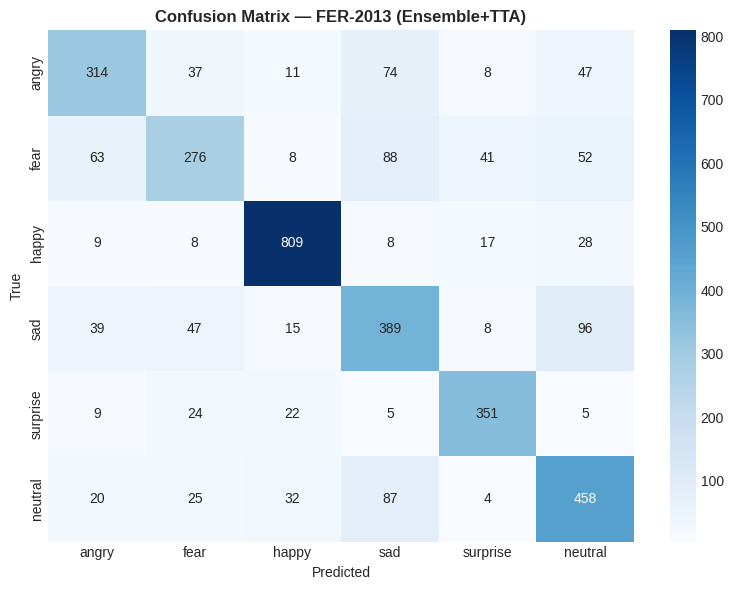


Evaluating on: RAF-DB
  VGGFace2: Acc=0.8851 F1m=0.8319 F1w=0.8844
  DenseNet: Acc=0.8920 F1m=0.8440 F1w=0.8920



  Ensemble+TTA: Acc=0.9061 F1m=0.8633 F1w=0.9057 MCC=0.8725 Kappa=0.8722
  [local ✓] results/classification_report_raf-db.csv
    [☁ Drive ✓] results/classification_report_raf-db.csv

  Classification Report:
              precision    recall  f1-score   support

       angry       0.87      0.86      0.86       162
        fear       0.87      0.61      0.71        74
       happy       0.96      0.95      0.96      1185
         sad       0.88      0.86      0.87       478
    surprise       0.90      0.90      0.90       329
     neutral       0.85      0.91      0.88       680

    accuracy                           0.91      2908
   macro avg       0.89      0.85      0.86      2908
weighted avg       0.91      0.91      0.91      2908

  [local ✓] plots/confusion_matrix_raf-db.png
    [☁ Drive ✓] plots/confusion_matrix_raf-db.png


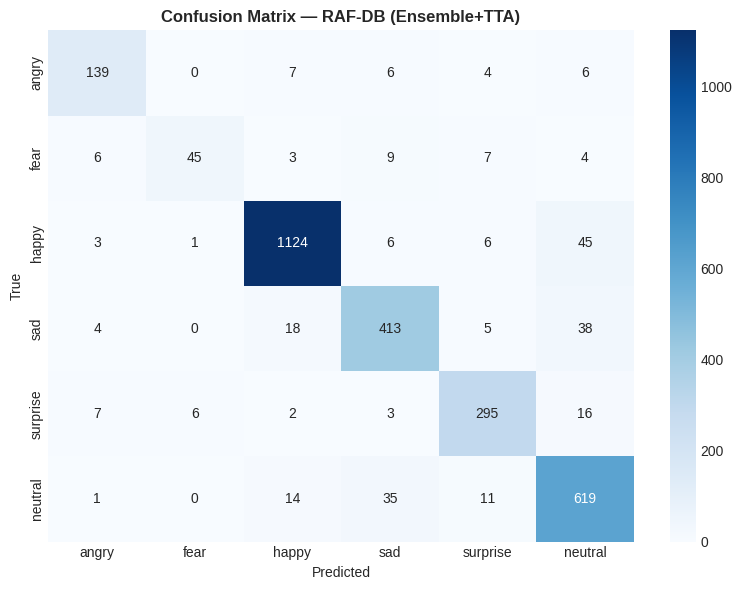


Evaluating on: AffectNet
  VGGFace2: Acc=0.7595 F1m=0.7283 F1w=0.7472
  DenseNet: Acc=0.7710 F1m=0.7424 F1w=0.7612



  Ensemble+TTA: Acc=0.7727 F1m=0.7437 F1w=0.7615 MCC=0.7306 Kappa=0.7242
  [local ✓] results/classification_report_affectnet.csv
    [☁ Drive ✓] results/classification_report_affectnet.csv

  Classification Report:
              precision    recall  f1-score   support

       angry       0.87      0.62      0.73      1718
        fear       0.79      0.49      0.61      1664
       happy       0.93      0.93      0.93      2704
         sad       0.65      0.99      0.78      1584
    surprise       0.66      0.51      0.58      1920
     neutral       0.74      0.96      0.84      2368

    accuracy                           0.77     11958
   macro avg       0.77      0.75      0.74     11958
weighted avg       0.78      0.77      0.76     11958

  [local ✓] plots/confusion_matrix_affectnet.png
    [☁ Drive ✓] plots/confusion_matrix_affectnet.png


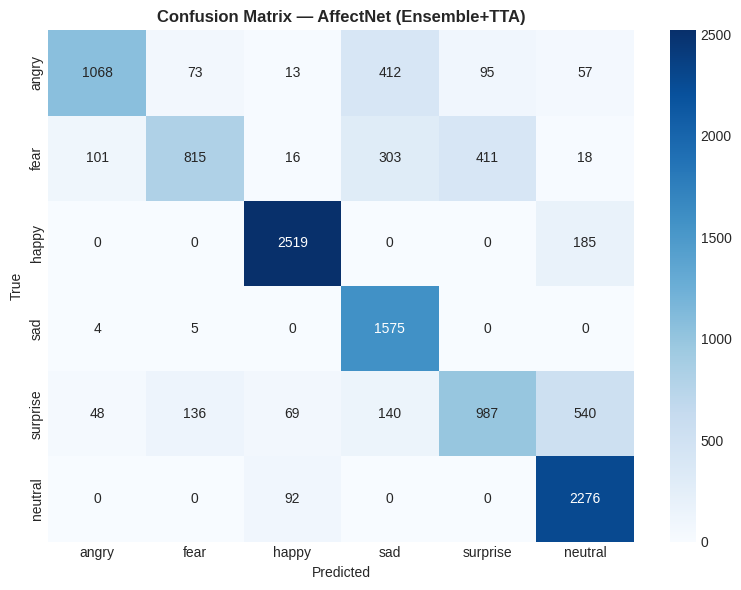

In [ ]:
# Run per-source evaluations (using face-filtered test loaders)
print('\n' + '='*60)
print('Per-Source Evaluation (Face-Filtered Test Sets)')
print('='*60)

results_fer = full_evaluation(model_a, model_b, 'FER-2013', test_loaders['fer']) if test_loaders['fer'] else None
results_raf = full_evaluation(model_a, model_b, 'RAF-DB', test_loaders['rafdb']) if test_loaders['rafdb'] else None
results_affect = full_evaluation(model_a, model_b, 'AffectNet', test_loaders['affectnet']) if test_loaders['affectnet'] else None

# Run global evaluation (all test sources combined)
print('\n' + '='*60)
print('Global Evaluation (All Face-Filtered Test Samples)')
print('='*60)
results_global = full_evaluation(model_a, model_b, 'GLOBAL', global_test_loader)

## 12. Training History Plots

  [local ✓] plots/history_EfficientNet_B3.png
    [☁ Drive ✓] plots/history_EfficientNet_B3.png


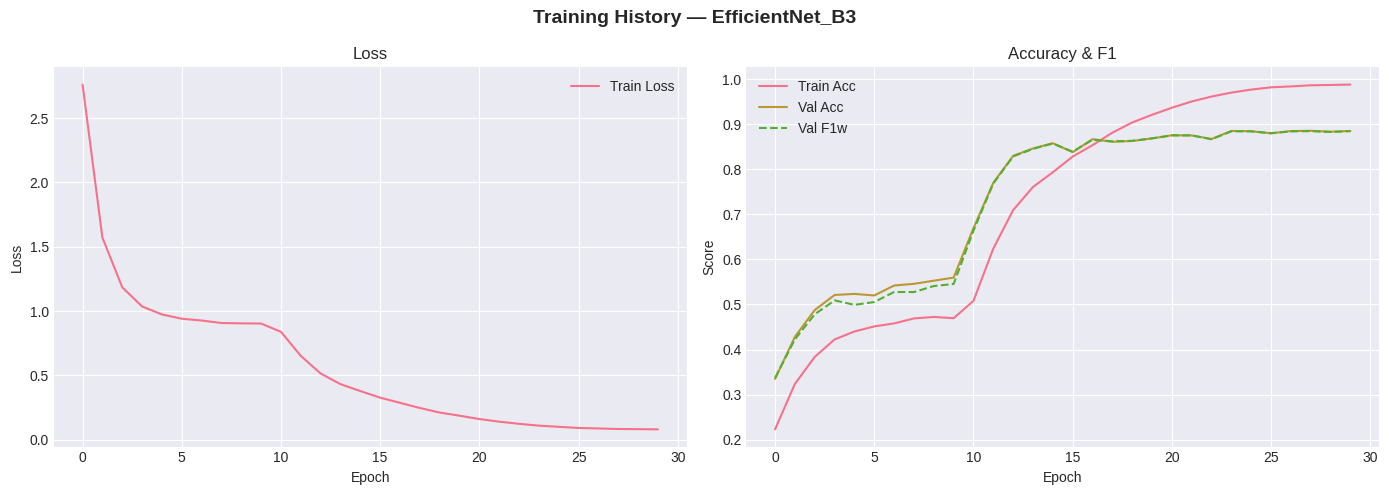

  [local ✓] plots/history_DenseNet121.png
    [☁ Drive ✓] plots/history_DenseNet121.png


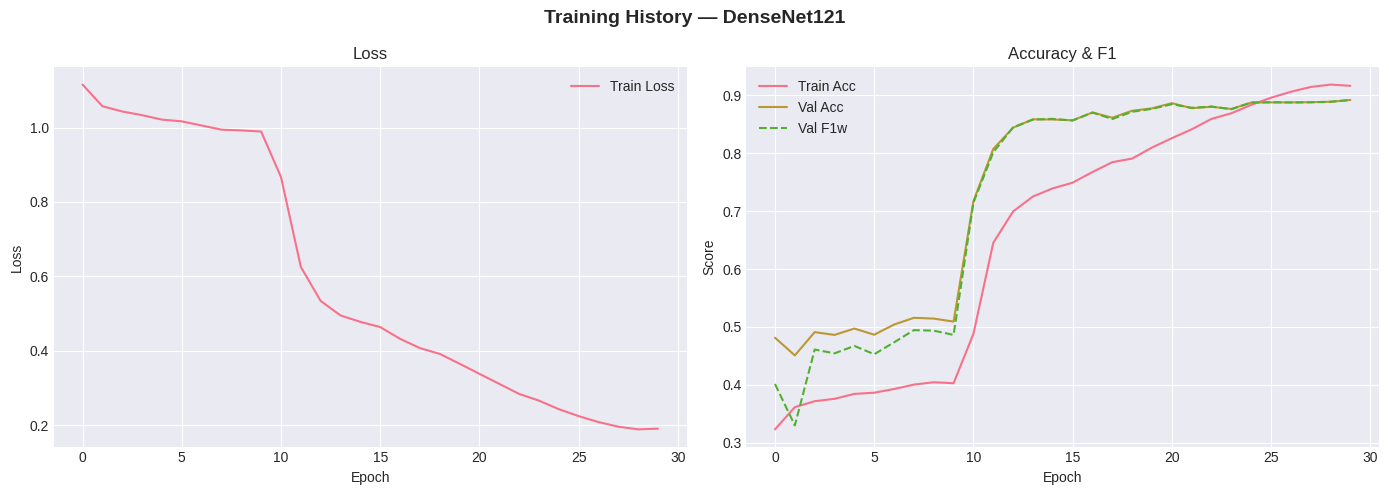

In [22]:
def plot_training_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {model_name}', fontsize=14, fontweight='bold')

    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].plot(history['val_f1'], label='Val F1w', linestyle='--')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Score')
    axes[1].set_title('Accuracy & F1')
    axes[1].legend()

    plt.tight_layout()
    save_figure(fig, f'history_{model_name}.png')
    plt.show()

plot_training_history(history_a, 'EfficientNet_B3')
plot_training_history(history_b, 'DenseNet121')

## 13. Final Summary & Sync

In [ ]:
# === Save final summary ===
summary = {
    'models': ['EfficientNet-B3', 'DenseNet-121'],
    'ensemble_weights': {'efficientnet': 0.5, 'densenet': 0.5},
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'train_samples': len(train_expanded),  # Augmented training set size
    'fer_test': results_fer['accuracy'] if results_fer else None,
    'raf_test': results_raf['accuracy'] if results_raf else None,
    'affect_test': results_affect['accuracy'] if results_affect else None,
}

summary_path = RESULTS_DIR / 'final_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
save_result(summary_path)

print('\n' + '=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
for ds, res in [('FER-2013', results_fer), ('RAF-DB', results_raf), ('AffectNet', results_affect)]:
    if res:
        print(f'  {ds:12s}: Acc={res["accuracy"]:.4f}  F1w={res["f1_weighted"]:.4f}  MCC={res["mcc"]:.4f}')
    else:
        print(f'  {ds:12s}: N/A (no test set)')

# Final sync
sync_all_to_drive()

print('\n✓ Pipeline complete!')

  [local ✓] results/final_summary.json
    [☁ Drive ✓] results/final_summary.json

FINAL RESULTS SUMMARY
  FER-2013    : Acc=0.7349  F1w=0.7327  MCC=0.6780
  RAF-DB      : Acc=0.9061  F1w=0.9057  MCC=0.8725
  AffectNet   : Acc=0.7727  F1w=0.7615  MCC=0.7306

Full Drive sync starting...
  Syncing 2 files → Drive/Unified_FER_Pipeline/models/
  Syncing 6 files → Drive/Unified_FER_Pipeline/plots/
  Syncing 4 files → Drive/Unified_FER_Pipeline/results/
Drive sync complete.

✓ Pipeline complete!
